# Task 5 — Panorama Image Stitching

**Member 3** | Merge overlapping images into a panorama.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from cv_utils import load_image, show_image, show_images_row
from tasks.task5_panorama_stitching import detect_and_match, compute_homography, warp_and_stitch, crop_black_borders, stitch_pair

print("✅ Imports OK")

✅ Imports OK


## 1. Load Overlapping Image Pair

Take two photos of the same scene with ~30-50% overlap.

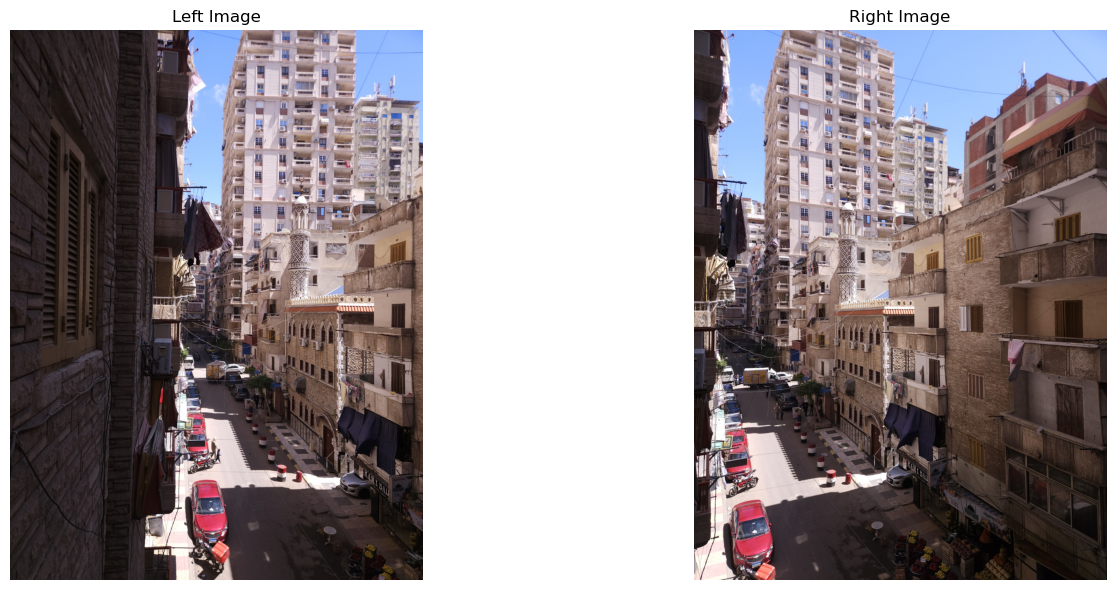

In [2]:
left = load_image('../images/task5/1.jpg')   # <-- CHANGE THIS
right = load_image('../images/task5/2.jpg')  # <-- CHANGE THIS

show_images_row([left, right], ["Left Image", "Right Image"], figsize=(16, 6))

## 2. Feature Detection & Matching

  Keypoints: img1=13354, img2=13874
  Good matches: 4808
Keypoints: left=13354, right=13874
Good matches: 4808


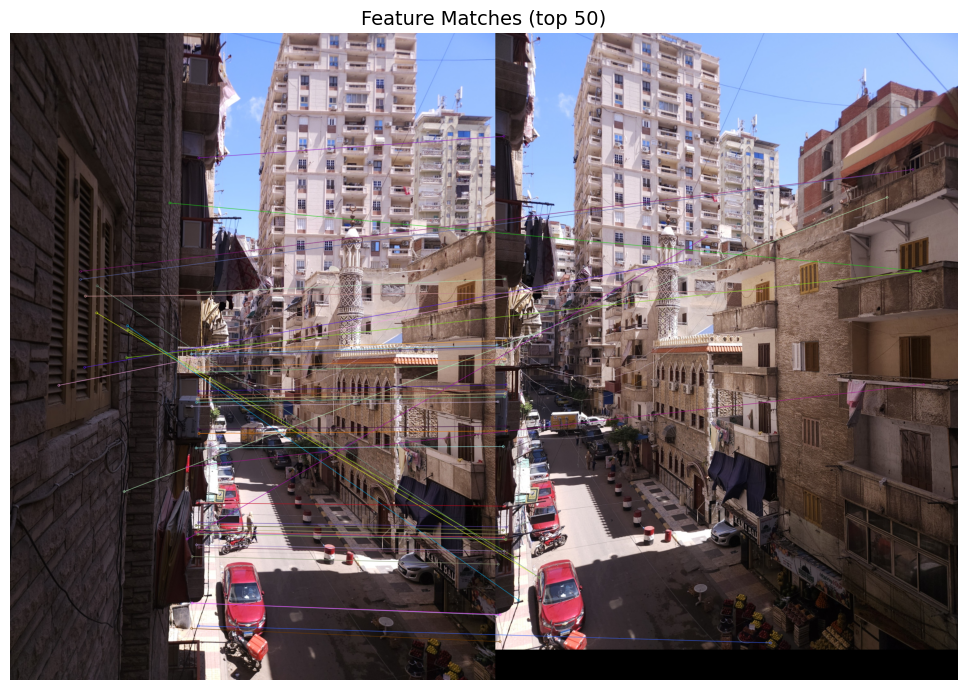

In [3]:
kp1, kp2, good_matches, match_img = detect_and_match(left, right, method="sift")

print(f"Keypoints: left={len(kp1)}, right={len(kp2)}")
print(f"Good matches: {len(good_matches)}")

show_image(match_img, "Feature Matches (top 50)", figsize=(18, 7))

## 3. Compute Homography

In [4]:
H, mask = compute_homography(kp1, kp2, good_matches)
if H is not None:
    print("Homography matrix:")
    print(H)
    inliers = mask.ravel().sum()
    print(f"\nInliers: {inliers}/{len(good_matches)}")

  Homography inliers: 4111/4808
Homography matrix:
[[ 1.52603378e+00  1.21341942e-02 -7.97026128e+02]
 [ 3.81562786e-01  1.31825421e+00 -3.20409320e+02]
 [ 4.45031876e-04 -1.27168396e-05  1.00000000e+00]]

Inliers: 4111/4808


## 4. Warp & Stitch

  Keypoints: img1=13354, img2=13874
  Good matches: 4808
  Homography inliers: 4111/4808


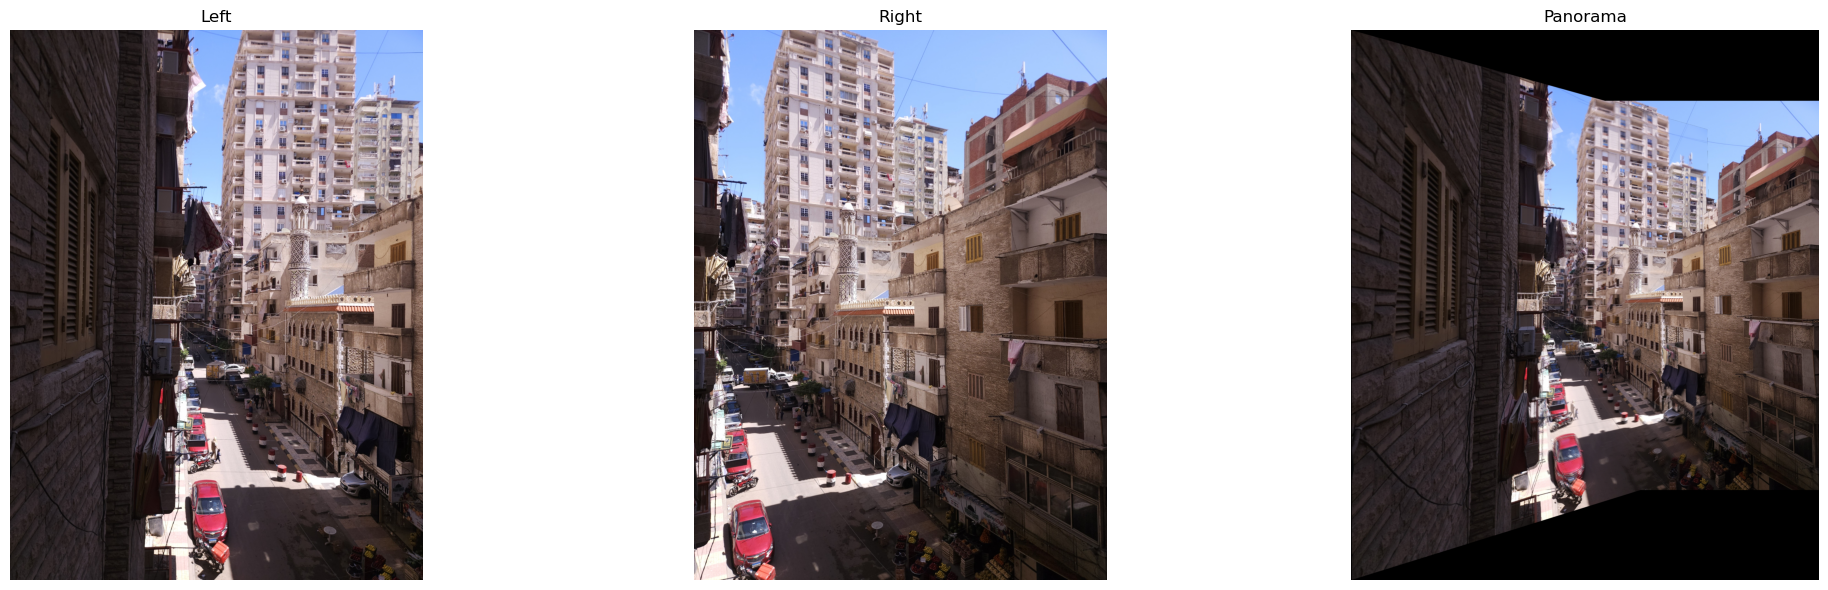

In [5]:
panorama, match_vis = stitch_pair(left, right)

if panorama is not None:
    show_images_row([left, right, panorama],
                   ["Left", "Right", "Panorama"],
                   figsize=(22, 6))

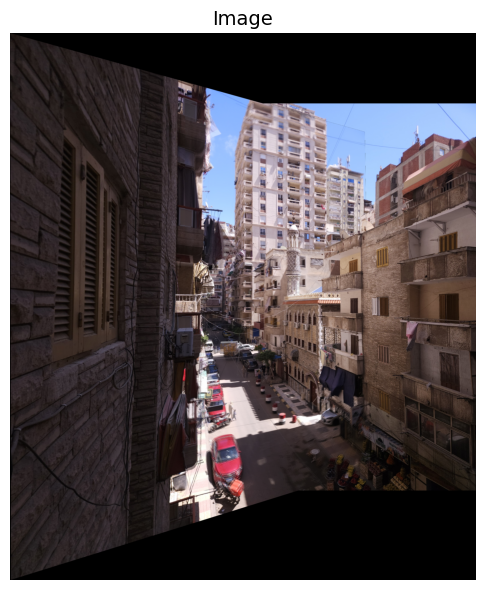

In [9]:
show_image(panorama)

## 5. Save Results

In [6]:
os.makedirs('../outputs/task5', exist_ok=True)
if panorama is not None:
    cv2.imwrite('../outputs/task5/panorama.png', panorama)
if match_img is not None:
    cv2.imwrite('../outputs/task5/matches.png', match_img)
print("✅ Saved to outputs/task5/")

✅ Saved to outputs/task5/
